## CSV 3: Ambiguous & Misleading Column Names (Semantic Confusion)

**Description**  
A poorly standardized sales system export with non-standard, vague column names. Revenue, pricing, and date semantics are unclear, with multiple numeric fields that could represent monetary values and no explicitly named revenue or order date columns.

**Purpose / What It Tests**
- Semantic inference and reasoning under ambiguity
- Ability to identify or question revenue and date fields
- Avoidance of incorrect assumptions
- Quality of column meaning explanations  
- Critical black-box evaluation of agent decision-making


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

np.random.seed(21)

N_ROWS = 2800

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date(start, end):
    return start + timedelta(days=random.randint(0, (end - start).days))

items = [
    ("SKU-101", "CRM Pro", "Software"),
    ("SKU-102", "Analytics Suite", "Software"),
    ("SKU-201", "POS Terminal", "Hardware"),
]

areas = ["NA", "EU", "APAC"]
sources = ["Web", "ColdCall", "Partner"]
agents = [f"Agent_{i}" for i in range(1, 12)]

rows = []

for i in range(N_ROWS):
    item_id, item_name, group = random.choice(items)
    qty = random.randint(1, 25)

    unit_cost = random.randint(100, 1800)
    gross_value = qty * unit_cost  # This is actually revenue

    rows.append({
        "deal_ref": f"D-{300000+i}",
        "client_ref": f"CL-{random.randint(2000, 8000)}",
        "event_time": random_date(start_date, end_date),
        "item_code": item_id,
        "item_label": item_name,
        "grouping": group,
        "qty": qty,
        "price": unit_cost,         # ambiguous: unit or total?
        "amount": gross_value,      # ambiguous but actually revenue
        "value": gross_value + random.randint(-50, 50),  # noisy duplicate
        "territory": random.choice(areas),
        "source": random.choice(sources),
        "owner": random.choice(agents),
        "status": random.choice(["Closed", "Won", "Lost"]),
    })

df = pd.DataFrame(rows)

df.to_csv("sales_ambiguous_columns.csv", index=False)
print("CSV generated: sales_ambiguous_columns.csv")


CSV generated: sales_ambiguous_columns.csv


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_ambiguous_columns.csv")

# Check absence of explicit revenue column
assert "revenue" not in df.columns, "❌ Revenue column should not exist"

# Multiple monetary-looking columns
numeric_cols = df.select_dtypes(include="number").columns.tolist()
print("Numeric columns:", numeric_cols)

assert {"price", "amount", "value"}.issubset(set(numeric_cols)), \
    "❌ Ambiguous monetary columns missing"

# Check correlation between amount and qty * price
calculated = df["qty"] * df["price"]
correlation = calculated.corr(df["amount"])
print("Correlation (qty*price vs amount):", correlation)

assert correlation > 0.95, "❌ 'amount' does not clearly behave like revenue"

# Date ambiguity
assert "event_time" in df.columns and "order_date" not in df.columns, \
    "❌ Date ambiguity condition not met"

print("✅ Semantic ambiguity successfully validated.")


Numeric columns: ['qty', 'price', 'amount', 'value']
Correlation (qty*price vs amount): 1.0
✅ Semantic ambiguity successfully validated.


Gold Truth Analysis

Total Revenue: 10933999
Average Deal Value: 11975.90251916758


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_70380\3287748751.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["amount"]


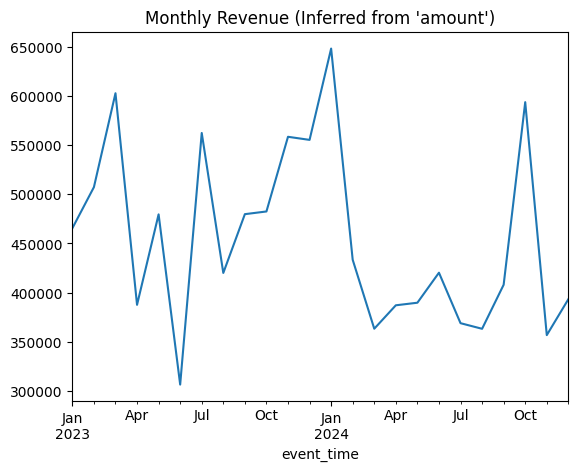

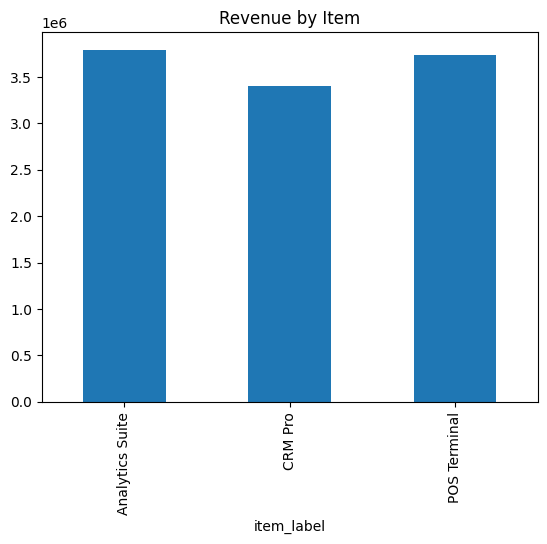

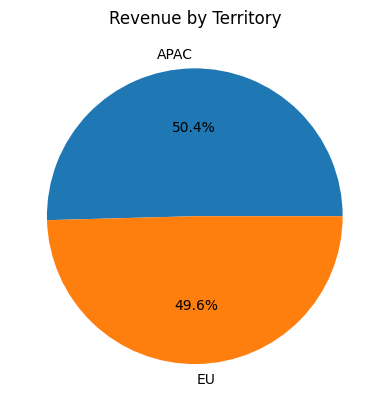

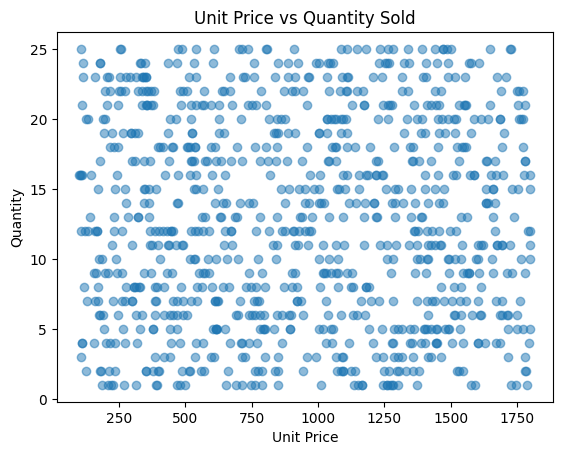

Win Rate: 0.32607142857142857


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    "sales_ambiguous_columns.csv",
    parse_dates=["event_time"]
)

# Filter only won deals
won = df[df["status"] == "Won"]

# ---------------------------
# KPI 1: Total Revenue
# ---------------------------
total_revenue = won["amount"].sum()
print("Total Revenue:", total_revenue)

# ---------------------------
# KPI 2: Average Deal Value
# ---------------------------
avg_deal_value = won["amount"].mean()
print("Average Deal Value:", avg_deal_value)

# ---------------------------
# Trend 1: Monthly Revenue Trend
# ---------------------------
monthly_revenue = (
    won.set_index("event_time")
       .resample("M")["amount"]
       .sum()
)

monthly_revenue.plot(title="Monthly Revenue (Inferred from 'amount')")
plt.show()

# ---------------------------
# Trend 2: Revenue by Item
# ---------------------------
item_revenue = won.groupby("item_label")["amount"].sum()
item_revenue.plot(kind="bar", title="Revenue by Item")
plt.show()

# ---------------------------
# Trend 3: Revenue by Territory
# ---------------------------
territory_revenue = won.groupby("territory")["amount"].sum()
territory_revenue.plot(kind="pie", autopct="%1.1f%%", title="Revenue by Territory")
plt.ylabel("")
plt.show()

# ---------------------------
# Trend 4: Unit Price vs Quantity
# ---------------------------
plt.scatter(won["price"], won["qty"], alpha=0.5)
plt.title("Unit Price vs Quantity Sold")
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.show()

# ---------------------------
# KPI 3: Win Rate
# ---------------------------
win_rate = (df["status"] == "Won").mean()
print("Win Rate:", win_rate)
